# ShanghaiTech Campus Dataset — EDA
Exploratory Data Analysis for the ShanghaiTech anomaly detection dataset.

**Dataset structure:**
```
shanghaitech/
├── training/
│   └── videos/          # Normal videos only (no anomalies in training)
└── testing/
    ├── frames/          # Pre-extracted frames per video
    └── test_frame_mask/ # Binary anomaly masks per frame
```

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import defaultdict
import cv2
import warnings
warnings.filterwarnings('ignore')

# ── Set your dataset root here ──────────────────────────────────────────────
DATASET_ROOT = Path(os.path.expanduser('~/Downloads/shanghaitech/shanghaitech'))
# ─────────────────────────────────────────────────────────────────────────────

TRAIN_VIDEOS = DATASET_ROOT / 'training' / 'videos'
TEST_FRAMES  = DATASET_ROOT / 'testing'  / 'frames'
TEST_MASKS   = DATASET_ROOT / 'testing'  / 'test_frame_mask'

print('Dataset root exists:', DATASET_ROOT.exists())
print('Training videos path:', TRAIN_VIDEOS.exists())
print('Testing frames path: ', TEST_FRAMES.exists())
print('Testing masks path:  ', TEST_MASKS.exists())

Dataset root exists: True
Training videos path: True
Testing frames path:  True
Testing masks path:   True


## 1. Dataset Overview

In [2]:
# ── Training set ─────────────────────────────────────────────────────────────
train_videos = sorted(TRAIN_VIDEOS.glob('*.avi'))
print(f'Training videos : {len(train_videos)}')

# ── Testing set ──────────────────────────────────────────────────────────────
# Testing videos are stored as frame folders
test_video_dirs = sorted([d for d in TEST_FRAMES.iterdir() if d.is_dir()])
print(f'Testing  videos : {len(test_video_dirs)}')

# Masks: .npy files, one per test video
mask_files = sorted(TEST_MASKS.glob('*.npy'))
print(f'Mask files      : {len(mask_files)}')

Training videos : 330
Testing  videos : 107
Mask files      : 107


In [3]:
# Scene IDs — derived from filename prefix (e.g. 01_001 → scene 01)
def scene_id(name):
    return name.split('_')[0]

train_scenes = sorted(set(scene_id(v.stem) for v in train_videos))
test_scenes  = sorted(set(scene_id(d.name) for d in test_video_dirs))

print(f'Training scenes : {train_scenes}')
print(f'Testing  scenes : {test_scenes}')
print(f'Total unique scenes: {len(set(train_scenes + test_scenes))}')

Training scenes : ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13']
Testing  scenes : ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12']
Total unique scenes: 13


## 2. Training Set Analysis

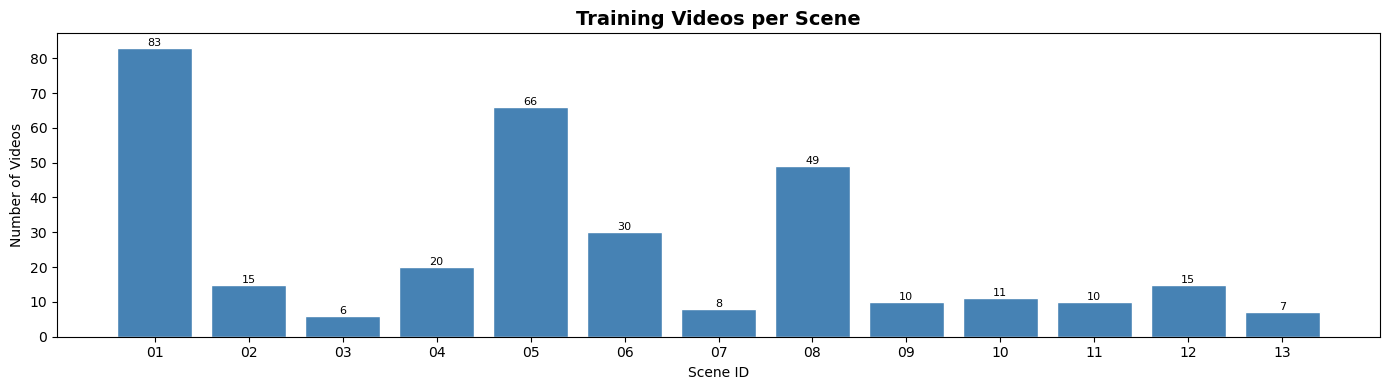

Scene  Videos
   01      83
   02      15
   03       6
   04      20
   05      66
   06      30
   07       8
   08      49
   09      10
   10      11
   11      10
   12      15
   13       7


In [4]:
# Count videos per scene in training set
train_scene_counts = defaultdict(int)
for v in train_videos:
    train_scene_counts[scene_id(v.stem)] += 1

train_scene_df = pd.DataFrame([
    {'Scene': k, 'Videos': v} for k, v in sorted(train_scene_counts.items())
])

fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(train_scene_df['Scene'], train_scene_df['Videos'], color='steelblue', edgecolor='white')
ax.set_title('Training Videos per Scene', fontsize=14, fontweight='bold')
ax.set_xlabel('Scene ID')
ax.set_ylabel('Number of Videos')
ax.bar_label(bars, fontsize=8)
plt.tight_layout()
plt.show()

print(train_scene_df.to_string(index=False))

In [5]:
# Frame counts for training videos using OpenCV
print('Counting frames in training videos (this may take a minute)...')

train_records = []
for vpath in train_videos:
    cap = cv2.VideoCapture(str(vpath))
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps      = cap.get(cv2.CAP_PROP_FPS)
    w        = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h        = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    duration = n_frames / fps if fps > 0 else 0
    train_records.append({
        'video': vpath.stem,
        'scene': scene_id(vpath.stem),
        'frames': n_frames,
        'fps': fps,
        'duration_s': duration,
        'width': w,
        'height': h
    })

train_df = pd.DataFrame(train_records)
print(f'\nTraining set summary:')
print(train_df[['frames','fps','duration_s']].describe().round(2))

Counting frames in training videos (this may take a minute)...



Training set summary:
        frames     fps  duration_s
count   330.00  330.00      330.00
mean    831.87   24.24       34.33
std     393.09    0.43       15.91
min     200.00   24.00        8.00
25%     649.25   24.00       27.04
50%     772.00   24.00       32.04
75%     958.25   24.00       39.83
max    4169.00   25.00      166.76


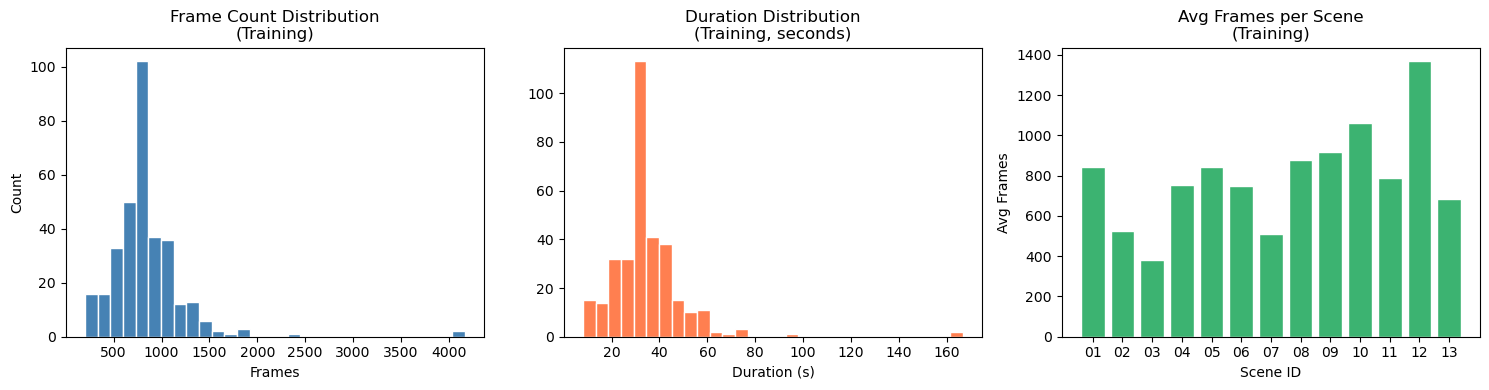

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(train_df['frames'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Frame Count Distribution\n(Training)')
axes[0].set_xlabel('Frames')
axes[0].set_ylabel('Count')

axes[1].hist(train_df['duration_s'], bins=30, color='coral', edgecolor='white')
axes[1].set_title('Duration Distribution\n(Training, seconds)')
axes[1].set_xlabel('Duration (s)')

scene_frames = train_df.groupby('scene')['frames'].mean()
axes[2].bar(scene_frames.index, scene_frames.values, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Avg Frames per Scene\n(Training)')
axes[2].set_xlabel('Scene ID')
axes[2].set_ylabel('Avg Frames')

plt.tight_layout()
plt.show()

## 3. Testing Set Analysis — Anomaly Masks

In [7]:
# Load mask files and compute anomaly statistics per video
test_records = []
for mf in mask_files:
    mask = np.load(str(mf))   # shape: (n_frames,) — 0=normal, 1=anomaly
    n_frames     = len(mask)
    n_anomaly    = int(mask.sum())
    n_normal     = n_frames - n_anomaly
    anomaly_rate = n_anomaly / n_frames if n_frames > 0 else 0
    test_records.append({
        'video': mf.stem,
        'scene': scene_id(mf.stem),
        'total_frames': n_frames,
        'anomaly_frames': n_anomaly,
        'normal_frames': n_normal,
        'anomaly_rate': anomaly_rate,
        'is_anomaly': n_anomaly > 0
    })

test_df = pd.DataFrame(test_records)

n_anomaly_vids = test_df['is_anomaly'].sum()
n_normal_vids  = (~test_df['is_anomaly']).sum()
print(f'Test videos with anomalies : {n_anomaly_vids}')
print(f'Test videos fully normal   : {n_normal_vids}')
print(f'Total test videos          : {len(test_df)}')
print(f'\nFrame-level breakdown:')
print(f'  Total frames    : {test_df["total_frames"].sum():,}')
print(f'  Anomaly frames  : {test_df["anomaly_frames"].sum():,}')
print(f'  Normal frames   : {test_df["normal_frames"].sum():,}')
total = test_df['total_frames'].sum()
print(f'  Anomaly ratio   : {test_df["anomaly_frames"].sum()/total*100:.1f}%')

Test videos with anomalies : 107
Test videos fully normal   : 0
Total test videos          : 107

Frame-level breakdown:
  Total frames    : 40,791
  Anomaly frames  : 17,326
  Normal frames   : 23,465
  Anomaly ratio   : 42.5%


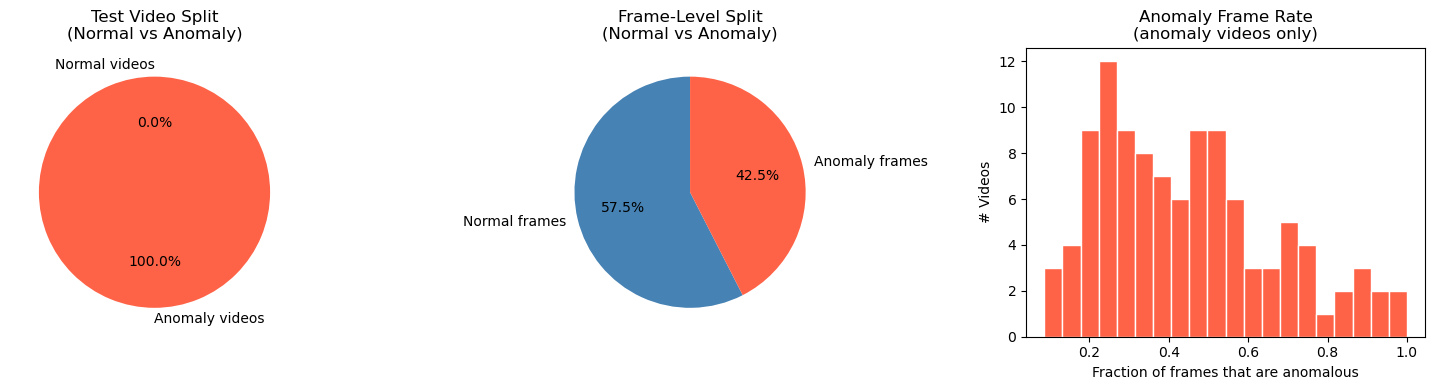

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Pie: normal vs anomaly videos
axes[0].pie(
    [n_normal_vids, n_anomaly_vids],
    labels=['Normal videos', 'Anomaly videos'],
    colors=['steelblue', 'tomato'],
    autopct='%1.1f%%', startangle=90
)
axes[0].set_title('Test Video Split\n(Normal vs Anomaly)')

# Frame-level pie
total_frames   = test_df['total_frames'].sum()
anomaly_frames = test_df['anomaly_frames'].sum()
normal_frames  = test_df['normal_frames'].sum()
axes[1].pie(
    [normal_frames, anomaly_frames],
    labels=['Normal frames', 'Anomaly frames'],
    colors=['steelblue', 'tomato'],
    autopct='%1.1f%%', startangle=90
)
axes[1].set_title('Frame-Level Split\n(Normal vs Anomaly)')

# Anomaly rate distribution across anomaly videos
anomaly_only = test_df[test_df['is_anomaly']]
axes[2].hist(anomaly_only['anomaly_rate'], bins=20, color='tomato', edgecolor='white')
axes[2].set_title('Anomaly Frame Rate\n(anomaly videos only)')
axes[2].set_xlabel('Fraction of frames that are anomalous')
axes[2].set_ylabel('# Videos')

plt.tight_layout()
plt.show()

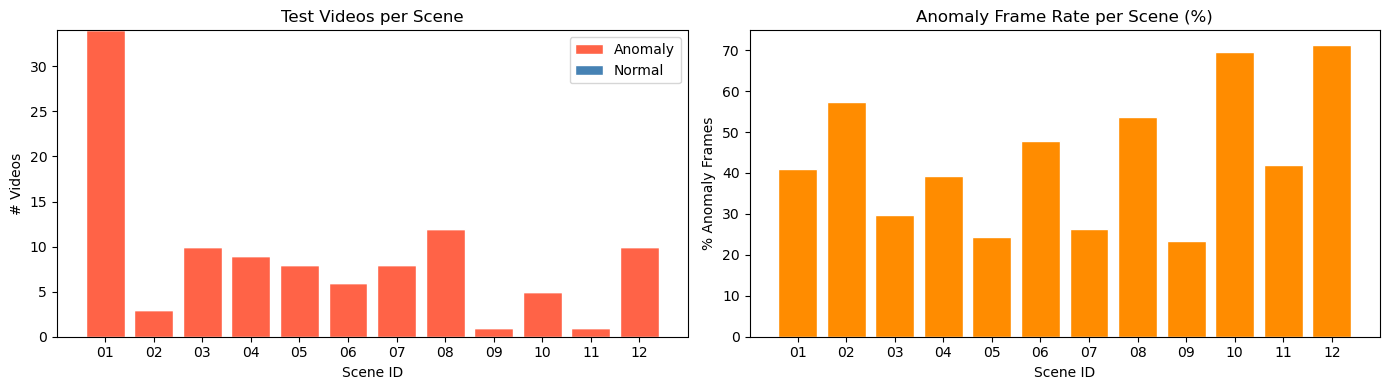

scene  total_videos  anomaly_videos  total_frames  anomaly_frames  frame_anomaly_rate
   01            34              34         11894            4884            0.410627
   02             3               3          1155             662            0.573160
   03            10              10          4090            1212            0.296333
   04             9               9          4761            1874            0.393615
   05             8               8          4160            1016            0.244231
   06             6               6          1470             702            0.477551
   07             8               8          3368             886            0.263064
   08            12              12          3708            1992            0.537217
   09             1               1           361              84            0.232687
   10             5               5          2213            1539            0.695436
   11             1               1           337     

In [9]:
# Per-scene breakdown of anomaly rate
scene_stats = test_df.groupby('scene').agg(
    total_videos=('video','count'),
    anomaly_videos=('is_anomaly','sum'),
    total_frames=('total_frames','sum'),
    anomaly_frames=('anomaly_frames','sum')
).reset_index()
scene_stats['frame_anomaly_rate'] = scene_stats['anomaly_frames'] / scene_stats['total_frames']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(scene_stats['scene'], scene_stats['anomaly_videos'],
            color='tomato', edgecolor='white', label='Anomaly')
axes[0].bar(scene_stats['scene'],
            scene_stats['total_videos'] - scene_stats['anomaly_videos'],
            bottom=scene_stats['anomaly_videos'],
            color='steelblue', edgecolor='white', label='Normal')
axes[0].set_title('Test Videos per Scene')
axes[0].set_xlabel('Scene ID')
axes[0].set_ylabel('# Videos')
axes[0].legend()

axes[1].bar(scene_stats['scene'], scene_stats['frame_anomaly_rate'] * 100,
            color='darkorange', edgecolor='white')
axes[1].set_title('Anomaly Frame Rate per Scene (%)')
axes[1].set_xlabel('Scene ID')
axes[1].set_ylabel('% Anomaly Frames')

plt.tight_layout()
plt.show()

print(scene_stats.to_string(index=False))

## 4. Temporal Anomaly Pattern Visualization

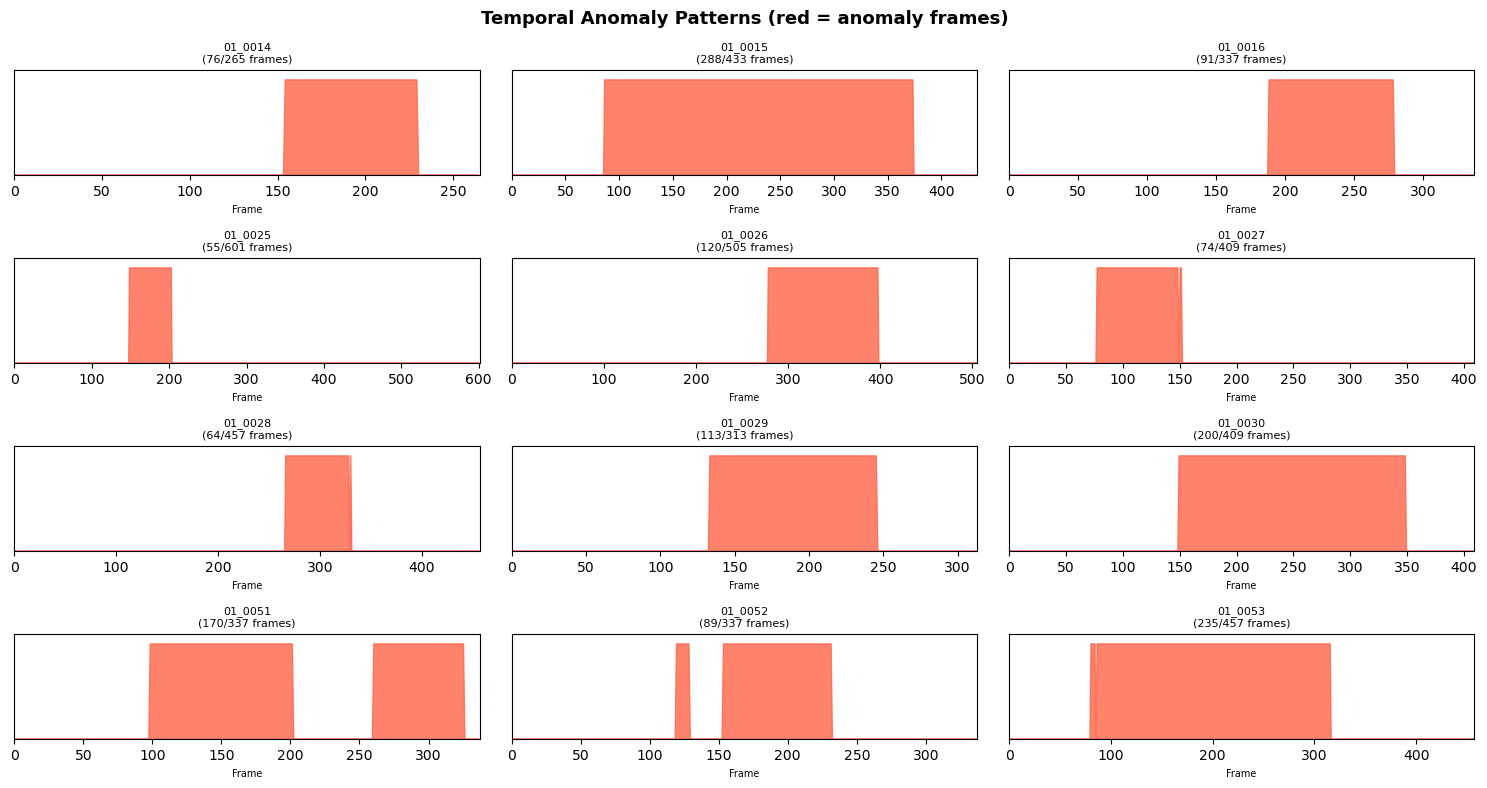

In [10]:
# Show the temporal anomaly pattern for the first 12 anomaly test videos
anomaly_videos = test_df[test_df['is_anomaly']].head(12)

fig, axes = plt.subplots(4, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (_, row) in enumerate(anomaly_videos.iterrows()):
    mask_path = TEST_MASKS / f"{row['video']}.npy"
    mask = np.load(str(mask_path))
    axes[i].fill_between(range(len(mask)), mask, color='tomato', alpha=0.8)
    axes[i].set_title(f"{row['video']}\n({row['anomaly_frames']}/{row['total_frames']} frames)",
                      fontsize=8)
    axes[i].set_xlim(0, len(mask))
    axes[i].set_ylim(0, 1.1)
    axes[i].set_yticks([])
    axes[i].set_xlabel('Frame', fontsize=7)

plt.suptitle('Temporal Anomaly Patterns (red = anomaly frames)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Sample Frame Visualization

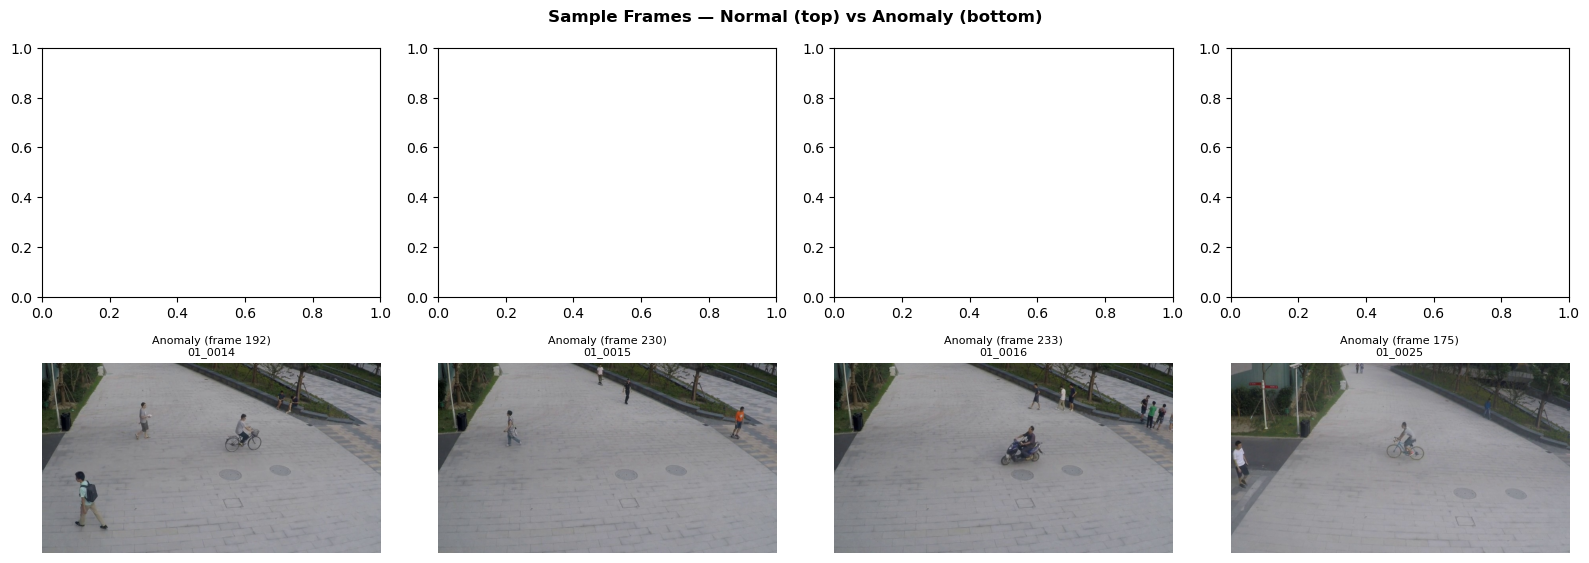

In [11]:
# Show sample normal and anomaly frames side by side from test set
def get_sample_frame(video_dir, frame_idx):
    """Load frame image from testing/frames/<video>/<frame>.jpg"""
    frames = sorted(video_dir.glob('*.jpg')) + sorted(video_dir.glob('*.png'))
    if not frames or frame_idx >= len(frames):
        return None
    img = cv2.imread(str(frames[frame_idx]))
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

fig, axes = plt.subplots(2, 4, figsize=(16, 6))

# Top row: normal frames (from a normal-only video)
normal_vids = test_df[~test_df['is_anomaly']].head(4)
for col, (_, row) in enumerate(normal_vids.iterrows()):
    vdir = TEST_FRAMES / row['video']
    img = get_sample_frame(vdir, 10)
    if img is not None:
        axes[0, col].imshow(img)
    axes[0, col].set_title(f"Normal\n{row['video']}", fontsize=8)
    axes[0, col].axis('off')

# Bottom row: anomaly frames (pick a frame inside the anomaly segment)
anomaly_vids = test_df[test_df['is_anomaly']].head(4)
for col, (_, row) in enumerate(anomaly_vids.iterrows()):
    mask = np.load(str(TEST_MASKS / f"{row['video']}.npy"))
    anomaly_idxs = np.where(mask == 1)[0]
    pick = int(anomaly_idxs[len(anomaly_idxs)//2]) if len(anomaly_idxs) > 0 else 0
    vdir = TEST_FRAMES / row['video']
    img = get_sample_frame(vdir, pick)
    if img is not None:
        axes[1, col].imshow(img)
    axes[1, col].set_title(f"Anomaly (frame {pick})\n{row['video']}", fontsize=8)
    axes[1, col].axis('off')

plt.suptitle('Sample Frames — Normal (top) vs Anomaly (bottom)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Summary Statistics

In [12]:
print('=' * 55)
print('  SHANGHAITECH CAMPUS DATASET — SUMMARY')
print('=' * 55)
print(f'  Unique scenes              : {len(set(train_scenes + test_scenes))}')
print()
print('  TRAINING SET (normal videos only)')
print(f'    Total videos             : {len(train_videos)}')
print(f'    Avg frames/video         : {train_df["frames"].mean():.0f}')
print(f'    Avg duration             : {train_df["duration_s"].mean():.1f}s')
print()
print('  TESTING SET')
print(f'    Total videos             : {len(test_df)}')
print(f'    Normal videos            : {n_normal_vids}')
print(f'    Anomaly videos           : {n_anomaly_vids}')
print(f'    Total test frames        : {test_df["total_frames"].sum():,}')
print(f'    Anomaly frames           : {test_df["anomaly_frames"].sum():,} ({test_df["anomaly_frames"].sum()/test_df["total_frames"].sum()*100:.1f}%)')
print(f'    Avg anomaly rate         : {test_df[test_df["is_anomaly"]]["anomaly_rate"].mean()*100:.1f}% per anomaly video')
print('=' * 55)

  SHANGHAITECH CAMPUS DATASET — SUMMARY
  Unique scenes              : 13

  TRAINING SET (normal videos only)
    Total videos             : 330
    Avg frames/video         : 832
    Avg duration             : 34.3s

  TESTING SET
    Total videos             : 107
    Normal videos            : 0
    Anomaly videos           : 107
    Total test frames        : 40,791
    Anomaly frames           : 17,326 (42.5%)
    Avg anomaly rate         : 44.7% per anomaly video
